In [ ]:
import os

def read_txt_files_with_different_encodings(folder_path):
    # 定义常见的编码方式
    encodings = ['utf-8-sig', 'gb18030', 'gbk', 'big5', 'latin1', 'iso-8859-1']
    
    # 初始化存储文件内容和文件名的列表
    file_contents = []
    file_names = []
    
    # 遍历指定文件夹中的所有文件
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            # 尝试不同的编码方式读取文件
            for encoding in encodings:
                try:
                    with open(file_path, 'rb') as file:
                        content = file.read().decode(encoding)
                    # 如果成功读取，则存储内容并跳出循环
                    file_contents.append(content)
                    file_names.append(filename[:-4])  # 去掉.txt后缀
                    break
                except UnicodeDecodeError:
                    continue
            else:
                # 如果所有编码方式都失败，打印错误信息
                print(f"无法解码文件: {filename}")
    
    return file_contents, file_names

# 示例使用
folder_path = 'C:\Users\ASUS\Desktop\研一（下）\dlnlp\第二次大作业\jyxstxtqj_downcc.com'
contents, names = read_txt_files_with_different_encodings(folder_path)

for items in contents:
    print("文件内容:", items[500:1000])
print("文件标题:", names)

文件内容: 个剑客的故事我知道得不全。但反正是写小说，不知道原来出典的，不妨任意创造一个故事。可是连写三十三个剑侠故事的心愿，永远也完成不了的。写了第一篇《越女剑》后，第二篇《虬髯客》的小说就写不下去了。写叙述文比写小说不费力得多，于是改用平铺直叙的方式，介绍原来的故事。其中《虬髯客》、《聂隐娘》、《红线》、《昆仑奴》四个故事众所周知，不再详细叙述，同时原文的文笔极好，我没有能力译成同样简洁明丽的语体文，所以附录了原文。比较生僻的故事则将原文内容全部写了出来。这些短文写于一九七○年一月和二月，是为《明报晚报》创刊最初两个月所作。
　　一 赵处女
　　江苏与浙江到宋朝时已渐渐成为中国的经济与文化中心，苏州、杭州成为出产文化和美女的地方。但在春秋战国时期，吴人和越人却是勇决剽悍的象征。那样的轻视生死，追求生命中最后一刹那的光彩，和现代一般中国人的性格相去是这么遥远，和现代苏浙人士的机智柔和更是两个极端。在那时候，吴人越人血管中所流动的，是原始的、犷野的热血。吴越的文化是外来的。伍子胥、文种、范蠡都来自西方的楚国。勾践的另一个重要谋士计然来自北方的晋国。只有西施本色的美丽，才原来就属于浣纱溪那清澈的
文件内容: 这玩意儿比甚么游戏都好玩，转到门口，推门进去，大叫：“老师，你教我这玩意儿！”
　　这女孩儿李沅芷是总兵李可秀的独生女儿，是他在湘西做参将任内所生，给女儿取这名字，是纪念生地之意。教书先生陆高止是位饱学宿儒，五十四五岁年纪，平日与李沅芷谈古论今，师生间倒也甚是相得。这一天陆高止因受不了青蝇苦扰，发射芙蓉金针，钉死了数十只，哪知却给女弟子在窗外偷看到了。他见李沅芷一张清秀明艳的脸蛋红扑扑地显得甚是兴奋，当下淡淡的道：“唔，怎么不跟女伴去玩儿，想听诸葛亮三气周瑜的故事，是不是？”李沅芷道：“老师，你教我这好玩的法儿？”陆高止道：“甚么法儿呀？”
　　李沅芷道：“用金针钉苍蝇的法儿。”说着搬了张椅子，纵身跳上，细细瞧了一会，把钉在苍蝇身上的金针一枚枚拔下来，用纸抹拭干净，交还老师，说道：“老师，我知道，你这不是玩意儿，是非常高明的武功，你非教我不可。”她有时跟随父亲在练武场上盘马弯弓，也学过一些武艺。陆高止微笑道：“你要学武功，扶风城周围几百里地，谁也及不上你爹爹武艺高强。”李沅芷道：“我爹爹只会用弓箭射鹰，可不会用金针射苍蝇，你若不信，我便问爹爹去，看他会不会。”
　

In [18]:
def load_words_from_file(file_path):
    """从文件中读取内容并返回一个集合"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return set(line.strip() for line in file)

def remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set):
    """去除文本中的标点符号和停用词"""
    # 去除标点符号
    text = ''.join(char for char in text if char not in punctuation_set)
    # 去除停用词
    words = text.split()
    words = [word for word in words if word not in stopwords_set]
    return ' '.join(words)

def process_text_list(text_list, punctuation_file, stopwords_file):
    """处理文本列表，去除标点符号和停用词"""
    # 加载标点符号和停用词
    punctuation_set = load_words_from_file(punctuation_file)
    stopwords_set = load_words_from_file(stopwords_file)
    print(stopwords_set)
    
    # 处理每个文本
    processed_list = []
    for text in text_list:
        processed_text = remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set)
        processed_list.append(processed_text)
    
    return processed_list

# 示例使用
text_list = contents
punctuation_file = 'cn_punctuation.txt'
stopwords_file = 'cn_stopwords.txt'

processed_list = process_text_list(text_list, punctuation_file, stopwords_file)

for items in processed_list:
    print(items[:2000])


{'旁人', '甚至于', '。', '呕', '！', '这就是说', '起', '与其', '哉', '及至', '谁', '此次', '什么样', '和', '们', '两者', '一方面', '来', '简言之', '这么', '不妨', '趁', '尚且', '要', '随后', '不仅', '赖以', '临', '仍', '另一方面', '本人', '曾', '能否', '啪达', '漫说', '看', '内', '喏', '别处', '若是', '第', '咱', '等', '前后', '光是', '凡', '再其次', '接着', '离', '关于', '余外', '谁人', '5', '这一来', '哪边', '只限', '啥', '此地', '着', '啷当', '设若', '么', '了', '顺', '除外', '所有', '吧哒', '个别', '任凭', '再则', '己', '紧接着', '从', '恰恰相反', '不管', '地', '人家', '“', '哪天', '本', '趁着', '介于', '反过来', '啐', '只有', '嘘', '一些', '这么点儿', '这会儿', '哼', '管', '哪个', '巴', '彼', '那', '9', '甚么', '呀', '一则', '此处', '宁肯', '不至于', '只要', '及', '当地', '诸位', '犹自', '这么些', '鄙人', '反过来说', '来自', '以及', '乃至', '归齐', '那会儿', '与', '你们', '先不先', '另', '云尔', '怎', '甚且', '而且', '自', '出来', '甚而', '（', '还', '？', '所幸', '又及', '哪年', '亦', '以至', '处在', '如此', '几', '矣乎', '谁料', '朝', '矣', '为', '当着', '别是', '沿着', '不独', '呗', '除非', '望', '固然', '好', '啊', '用来', '对待', '﹏', '遵循', '除开', '呼哧', '比如', '至于', '论', '不过', '些', '冒', '除此之外', '开始', '倘若', '也', '全体', '总而言之', '朝着', '依据', '如下'

In [19]:
import jieba

def load_stopwords(file_path):
    """从文件中加载停用词并返回一个集合"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return set(line.strip() for line in file)

def remove_stopwords(words, stopwords_set):
    """去除分词结果中的停用词"""
    return [word for word in words if word not in stopwords_set]

def process_text_list(text_list, stopwords_file):
    """处理文本列表，分词并去除停用词，最后取前500个分词"""
    # 加载停用词
    stopwords_set = load_stopwords(stopwords_file)
    
    # 处理每个文本
    processed_list = []
    i=0
    lll=len(text_list)
    for text in text_list:
        print(f"步骤已完成{i/lll*100} %")
        i+=1
        # 分词
        words = jieba.lcut(text)
        # 去除停用词
        words = remove_stopwords(words, stopwords_set)
        # 取前500个分词
        words = words
        processed_list.append(words)
    
    return processed_list

# 示例使用
text_list = processed_list
stopwords_file = 'cn_stopwords.txt'

processed_list1 = process_text_list(text_list, stopwords_file)


for items in processed_list1:
    print(items[:100])

步骤已完成0.0 %
步骤已完成6.25 %
步骤已完成12.5 %
步骤已完成18.75 %
步骤已完成25.0 %
步骤已完成31.25 %
步骤已完成37.5 %
步骤已完成43.75 %
步骤已完成50.0 %
步骤已完成56.25 %
步骤已完成62.5 %
步骤已完成68.75 %
步骤已完成75.0 %
步骤已完成81.25 %
步骤已完成87.5 %
步骤已完成93.75 %
['本书', 'wwwcr173com', '免费', 'txt', '小说', '下载站', ' ', '更', '更新', '免费', '电子书', '请', '关注', 'wwwcr173com', ' ', '三十', '三剑客', '图', ' ', '旧', '小说', '插图', '绣像', '我国', '向来', '传统', '喜欢', '读旧', '小说', '喜欢', '小说', '中', '插图', '可惜', '插图', '美术', '水准', '小说', '文学', '水准', '差得', '实在', '太远', '插图', '木版画', '雕刻', '木版', '印出来', '往往', '画得', '粗俗', '刻得', '简陋', '极少数', '例外', '我国', '版画', '悠久', '历史', '最古', '版画', '作品', '汉代', '肖形印', '印章', '上刻', '龙虎', '禽鸟', '图', '印印', '绢', '纸', '成为', '精美', '巧丽', '图形', '版画', '成长', '隋唐', '时', '佛画', '盛于宋', '元到', '明末', '登峰造极', '最大', '艺术家', '陈洪绶', '老莲', '清代', '版画', '普遍', '发展', '年画', '盛行于', '民间', '咸丰', '年间', '任渭长', '认为']
['本书', 'wwwcr173com', '免费', 'txt', '小说', '下载站', ' ', '更', '更新', '免费', '电子书', '请', '关注', 'wwwcr173com', ' ', '金庸', '书剑', '恩仇录', ' ', '第一回', ' ', '古道', '腾驹', '惊', '白发', ' ', '危峦', '快

In [20]:
'''
import pandas as pd
import re

# 示例数据（假设这是 jieba 分词的结果）
data = processed_list1

# 清洗非法字符的函数
def clean_illegal_characters(text):
    # 使用正则表达式去除控制字符（ASCII 0-31）和其他非法字符
    if isinstance(text, str):
        return re.sub(r'[\x00-\x1F\x7F]', '', text)
    return text

# 清洗数据
cleaned_data = [[clean_illegal_characters(word) for word in sublist] for sublist in data]

# 将列表转换为 DataFrame，每一列对应一个子列表
max_length = max(len(sublist) for sublist in cleaned_data)  # 找到最长的子列表长度
df = pd.DataFrame({f"Column_{i+1}": sublist + [""] * (max_length - len(sublist)) for i, sublist in enumerate(cleaned_data)})

# 保存到 Excel 文件
df.to_excel("preprocessed_saved.xlsx", index=False, engine="openpyxl")

print("数据已保存到 preprocessed_saved.xlsx")'
'''

'\nimport pandas as pd\nimport re\n\n# 示例数据（假设这是 jieba 分词的结果）\ndata = processed_list1\n\n# 清洗非法字符的函数\ndef clean_illegal_characters(text):\n    # 使用正则表达式去除控制字符（ASCII 0-31）和其他非法字符\n    if isinstance(text, str):\n        return re.sub(r\'[\x00-\x1f\x7f]\', \'\', text)\n    return text\n\n# 清洗数据\ncleaned_data = [[clean_illegal_characters(word) for word in sublist] for sublist in data]\n\n# 将列表转换为 DataFrame，每一列对应一个子列表\nmax_length = max(len(sublist) for sublist in cleaned_data)  # 找到最长的子列表长度\ndf = pd.DataFrame({f"Column_{i+1}": sublist + [""] * (max_length - len(sublist)) for i, sublist in enumerate(cleaned_data)})\n\n# 保存到 Excel 文件\ndf.to_excel("preprocessed_saved.xlsx", index=False, engine="openpyxl")\n\nprint("数据已保存到 preprocessed_saved.xlsx")\'\n'

In [21]:
import random

def extract_paragraphs(tokenized_texts, num_paragraphs=1000, paragraph_length=1000):
    paragraphs = []  # 存储抽取的段落
    source_indices = []  # 存储段落的来源文本索引

    # 确保输入的文本足够长以抽取段落
    valid_texts = [text for text in tokenized_texts if len(text) >= paragraph_length]
    if not valid_texts:
        raise ValueError("没有足够长的文本可供抽取段落。")

    for _ in range(num_paragraphs):
        # 随机选择一个文本
        source_index = random.randint(0, len(valid_texts) - 1)
        source_text = valid_texts[source_index]

        # 随机抽取一个段落
        start = random.randint(0, len(source_text) - paragraph_length)
        paragraph = source_text[start:start + paragraph_length]

        # 存储段落及其来源索引
        paragraphs.append(paragraph)
        source_indices.append(source_index)

    return paragraphs, source_indices

# 示例输入数据（假设这是分词后的文本列表）
tokenized_texts = processed_list1

# 抽取段落
paragraphs, source_indices = extract_paragraphs(tokenized_texts)

# 输出结果
print(f"抽取了 {len(paragraphs)} 个段落。")
print(f"第一个段落：{paragraphs[0]}")
print(f"第一个段落的来源文本索引：{source_indices[0]}")

抽取了 1000 个段落。
第一个段落：['用力', '两端', '抵住', '运', '内力', '一阵', '金币', '还给', '若克琳', '若克琳', '接', '过来', '想', '交给', '青青', '一拿上', '手', '不觉', '大吃一惊', '原来', '十多枚', '金币', '互相', '粘住', '结成', '一条', '圆柱', '竟然', '拉', '开来', '不禁', '睁', '圆圆的', '眼睛', '喃喃', '说道', '东方人', '真是', '神秘', '真是', '神秘', '回去', '金柱', '两个', '军官', '看雷蒙道', '人有', '魔术', '彼得', '道别', '惹', '走', '两人', '传下', '号令', '不一会', '听', '门外', '车', '声', '隆隆', '拖动', '大炮', '雷蒙', '彼得', '站', '起身', '走出', '店去', '若克琳', '走过', '青青', '身边', '时向', '嫣然一笑', '带', '一阵', '浓郁', '香风', '环', '珮', '叮噹', '出店', ' ', '铁罗汉', '道', '红夷', '大炮', '到底', '样子', '从来', '没见', '胡桂南', '道', '瞧瞧', '沙天广', '笑道', '胡兄', '妙手空空', '偷', '一尊', '大炮', '佩服', '胡桂南', '笑', '道', '大炮', '笨家伙', '倒', '真', '没', '偷过', '不要', '打个', '赌', '沙天广', '笑', '道', '大炮', '满清', '鞑子', '偷', '真要', '赌', '赌', '众人', '笑', '语声', '中出', '店', '一刻', '追过', '押运', '大炮', '军队', '见', '大炮', '共有', '十尊', '果是', '庞然大物', '单观', '其形', '威风凛凛', '每尊', '炮用', '八匹', '马', '拖拉', '后面', '夫役', '推送', '炮车', '过去', '路上', '压出', '两条', '深沟', ' ', '群雄', '驰出', '二十余里', '忽', '听', '前面'

In [22]:
def split_data(list1, list2, ratio=9):
    # 计算分割点
    split_point = int(len(list1) * ratio / (ratio + 1))
    
    # 分割第一个列表
    train_list1 = list1[:split_point]
    test_list1 = list1[split_point:]
    
    # 分割第二个列表
    train_list2 = list2[:split_point]
    test_list2 = list2[split_point:]
    
    return train_list1, test_list1, train_list2, test_list2



# 分割数据
train_list1, test_list1, train_list2, test_list2 = split_data(paragraphs,source_indices)

# 输出结果
for items in test_list2:
    print(items)
print(len(test_list1))
for items in test_list1:
    print(items[:20])
print(len(test_list1))

11
9
9
8
12
14
15
6
6
7
11
3
13
10
10
9
1
0
8
10
1
12
11
7
6
2
6
2
8
10
4
1
9
6
9
14
2
0
7
7
12
6
7
7
1
14
9
14
8
7
8
7
9
1
11
5
4
5
13
9
14
8
10
0
9
10
5
10
2
10
2
13
14
2
6
0
2
1
5
4
10
3
13
6
11
6
6
10
1
6
6
8
15
11
9
3
4
10
15
0
100
['转过', '头', '不敢', '瞧', ' ', '狄云使', '半天', '劲', '始终', '说不出', '一字', '忽见', '戚芳', '转头', '避开', '不由得', '心中', '大恸', '恨', '恨']
['厮打', '之象', ' ', '天色', '黑', '林震南', '教人', '提', '灯笼', '旁', '亲手', '解开', '郑镖头', '衣裤', '前前后后', '仔细', '察看', '周身', '骨骼', '捏']
['四位', '长老', '属下', '管教', '不严', '黑白子', '性情', '乖张', '近来', '大非', '昔比', '几日', '竟然', '庄中', '老者', '双目', '瞪视', '突然', '间', '眼中']
['双将', '整部', '心', '从头至尾', '记全', '反复', '背诵', '遗漏', '杨过', '每隔', ' ', '七日', '便服', '一次', '断肠草', '解毒', '服量', '逐次', '减少', ' ']
['鄙陋', '不明', '世事', '敝', '说', '称', '想来', '必定', '称得', '曹云奇', '听', '言语', '谦下', '神色', '极', '恭', '心中', '怒气', '上冲', '心想']
['什', '麽', '吵', '大爷', '头昏脑胀', '快快', '赔来', ' ', '那书生', '见', '四人', '情状', '吃', '一惊', '问道', '请问', '仁兄', '赔什', '麽', '盖一鸣']
['样子', '索性', '说道', '夏总兵', '放心', '相', '贵不可言', '日后'

In [23]:
from gensim.models import LdaModel
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

In [24]:
# 假设text_fragments是文本片段的分词列表，text_indices是对应的文本索引
text_fragments = processed_list1
text_indices = range(len(processed_list1))

In [25]:
from sklearn import svm
from gensim.models import LdaModel
import numpy as np

# 假设你已经有了训练好的LDA模型和训练数据
# lda_model: 训练好的LDA模型
# train_tokenized_texts: 第一个列表，包含分词后的文本片段
# train_text_indices: 第二个列表，包含每个文本片段对应的文本索引
from gensim.corpora import Dictionary

# 假设 tokenized_texts 是分词后的文本列表
tokenized_texts=processed_list1
dictionary = Dictionary(tokenized_texts)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

# 训练 LDA 模型
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=10)

def transform_to_lda_features(lda_model, tokenized_texts):
    """
    将分词后的文本片段转换为LDA主题分布向量
    """
    lda_features = []
    for tokens in tokenized_texts:
        # 手动构建词袋模型
        bow = [(lda_model.id2word.token2id[token], 1) for token in tokens if token in lda_model.id2word.token2id]
        topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0)
        topic_vector = [prob for _, prob in topic_distribution]  # 提取主题概率
        lda_features.append(topic_vector)
    return np.array(lda_features)

# 将训练数据转换为LDA特征

train_lda_features = transform_to_lda_features(lda_model, train_list1)

# 训练SVM模型
svm_model = svm.SVC()
svm_model.fit(train_lda_features, train_list2)

def predict_text_indices(lda_model, svm_model, new_tokenized_texts):
    """
    预测新文本片段的来源
    """
    # 将新文本片段转换为LDA特征
    new_lda_features = transform_to_lda_features(lda_model, new_tokenized_texts)
    
    # 使用SVM模型进行预测
    predicted_indices = svm_model.predict(new_lda_features)
    
    return predicted_indices.tolist()

# 示例：预测新文本片段的来源
new_tokenized_texts = test_list1

predicted_indices = predict_text_indices(lda_model, svm_model, new_tokenized_texts)
print(predicted_indices)

[11, 9, 9, 12, 12, 14, 15, 6, 14, 7, 11, 3, 13, 10, 10, 9, 4, 0, 12, 10, 1, 12, 5, 7, 14, 15, 6, 2, 4, 10, 4, 1, 9, 14, 7, 14, 2, 0, 12, 7, 12, 6, 12, 7, 1, 14, 9, 14, 11, 7, 12, 3, 13, 1, 11, 5, 4, 5, 13, 9, 14, 12, 10, 0, 7, 10, 5, 10, 15, 10, 2, 13, 14, 15, 6, 0, 2, 1, 5, 4, 10, 3, 13, 6, 11, 6, 14, 10, 1, 6, 14, 12, 15, 11, 9, 3, 4, 10, 15, 0]


In [26]:
print(test_list2)

[11, 9, 9, 8, 12, 14, 15, 6, 6, 7, 11, 3, 13, 10, 10, 9, 1, 0, 8, 10, 1, 12, 11, 7, 6, 2, 6, 2, 8, 10, 4, 1, 9, 6, 9, 14, 2, 0, 7, 7, 12, 6, 7, 7, 1, 14, 9, 14, 8, 7, 8, 7, 9, 1, 11, 5, 4, 5, 13, 9, 14, 8, 10, 0, 9, 10, 5, 10, 2, 10, 2, 13, 14, 2, 6, 0, 2, 1, 5, 4, 10, 3, 13, 6, 11, 6, 6, 10, 1, 6, 6, 8, 15, 11, 9, 3, 4, 10, 15, 0]


In [27]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(y_true, y_pred):
    """
    计算模型预测的准确率

    参数:
    y_true (list): 真实的文本索引列表
    y_pred (list): 模型预测的文本索引列表

    返回:
    float: 预测准确率
    """
    return accuracy_score(y_true, y_pred)

In [28]:
# 真实标签
true_indices = test_list2

# 预测标签
# predicted_indices = [0, 1, 2, 3, 0]  # 部分正确的情况

# 计算准确率
accuracy = calculate_accuracy(true_indices, predicted_indices)
print(f"模型预测准确率: {accuracy * 100:.2f}%")

模型预测准确率: 77.00%


In [29]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# 将训练数据转换为LDA特征
train_lda_features = transform_to_lda_features(lda_model, train_list1)

# 定义参数网格
param_grid = [
    {
        'C': [0.1, 1, 10, 100],  # 正则化参数
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],  # 核函数类型
        'gamma': ['scale', 'auto'],  # 核函数系数
        'degree': [2, 3, 4],  # 多项式核的阶数
        'class_weight': [None, 'balanced']  # 类别权重
    }
]

# 创建基础SVM模型
svm_model = svm.SVC()

# 设置网格搜索
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring='accuracy',  # 可以使用其他评估指标如'f1', 'precision', 'recall'
    cv=5,  # 5折交叉验证
    n_jobs=-1,  # 使用所有可用的CPU核心
    verbose=2  # 显示详细日志
)

# 执行网格搜索
grid_search.fit(train_lda_features, train_list2)

# 输出最佳参数组合
print("最佳参数组合: ", grid_search.best_params_)
print("最佳交叉验证分数: ", grid_search.best_score_)

# 使用最佳模型进行预测
best_svm_model = grid_search.best_estimator_

def predict_text_indices(lda_model, svm_model, new_tokenized_texts):
    """
    预测新文本片段的来源
    """
    # 将新文本片段转换为LDA特征
    new_lda_features = transform_to_lda_features(lda_model, new_tokenized_texts)
    
    # 使用SVM模型进行预测
    predicted_indices = svm_model.predict(new_lda_features)
    
    return predicted_indices.tolist()

# 示例：预测新文本片段的来源
new_tokenized_texts = test_list1
predicted_indices1 = predict_text_indices(lda_model, best_svm_model, new_tokenized_texts)
print("预测结果: ", predicted_indices1)

# 如果需要，可以输出分类报告
# 首先转换测试数据
'''
test_lda_features = transform_to_lda_features(lda_model, test_list1)
print(classification_report(test_list2, best_svm_model.predict(test_lda_features)))'
'''

Fitting 5 folds for each of 192 candidates, totalling 960 fits
最佳参数组合:  {'C': 100, 'class_weight': None, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
最佳交叉验证分数:  0.9444444444444444
预测结果:  [11, 9, 9, 8, 12, 14, 15, 6, 6, 7, 11, 3, 13, 10, 10, 9, 4, 0, 8, 10, 1, 8, 5, 7, 6, 2, 6, 2, 8, 10, 4, 1, 9, 6, 9, 14, 2, 0, 7, 7, 12, 6, 7, 7, 1, 14, 9, 14, 5, 7, 8, 3, 9, 1, 11, 5, 4, 5, 13, 9, 14, 8, 10, 0, 7, 10, 5, 10, 2, 10, 2, 13, 14, 2, 6, 0, 2, 1, 5, 4, 10, 3, 13, 6, 11, 6, 6, 10, 1, 6, 6, 8, 15, 11, 9, 3, 4, 10, 15, 0]


"\ntest_lda_features = transform_to_lda_features(lda_model, test_list1)\nprint(classification_report(test_list2, best_svm_model.predict(test_lda_features)))'\n"

In [30]:
# 真实标签
true_indices = test_list2

# 预测标签
# predicted_indices = [0, 1, 2, 3, 0]  # 部分正确的情况

# 计算准确率
accuracy1 = calculate_accuracy(true_indices, predicted_indices1)
print(f"模型预测准确率: {accuracy1 * 100:.2f}%")

模型预测准确率: 94.00%


In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_vs_predicted(y_true, y_pred):
    """
    绘制真实值 vs 预测值图，并以 y = x 直线为参考

    参数:
    y_true (list or np.array): 真实值列表
    y_pred (list or np.array): 预测值列表
    """
    # 将输入转换为 numpy 数组
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 创建画布
    plt.figure(figsize=(8, 6))

    # 绘制 y = x 参考线
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 
             color='red', linestyle='--', label='y = x')

    # 绘制真实值 vs 预测值的散点图
    plt.scatter(y_true, y_pred, alpha=0.6, label='预测值 vs 真实值')

    # 添加标题和标签
    plt.title('真实值 vs 预测值', fontsize=16)
    plt.xlabel('真实值', fontsize=14)
    plt.ylabel('预测值', fontsize=14)

    # 添加网格
    plt.grid(True, linestyle='--', alpha=0.6)

    # 显示图例
    plt.legend()

    # 显示图像
    plt.show()

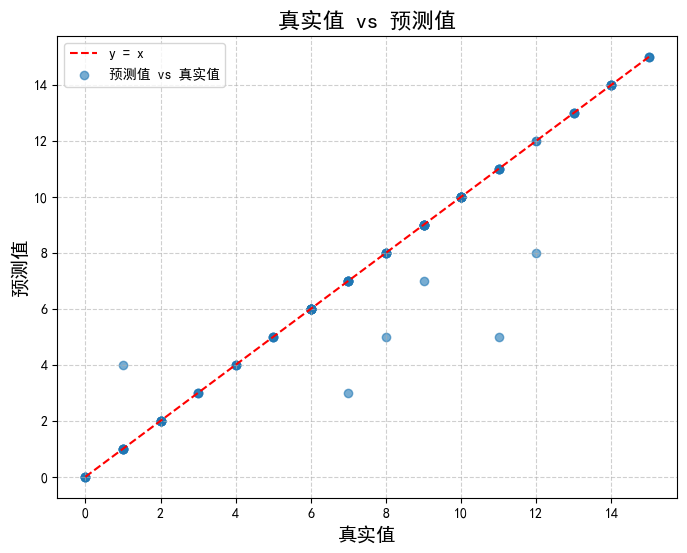

In [32]:
def plot_true_vs_predicted_with_accuracy(y_true, y_pred):
    """
    绘制真实值 vs 预测值图，并显示准确率
    """
    # 计算准确率
    accuracy = accuracy_score(y_true, y_pred)

    # 绘制图像
    plot_true_vs_predicted(y_true, y_pred)



    # 显示图像
    plt.show()

# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 使用示例
y_true = test_list2
y_pred = predicted_indices1
plot_true_vs_predicted_with_accuracy(y_true, y_pred)

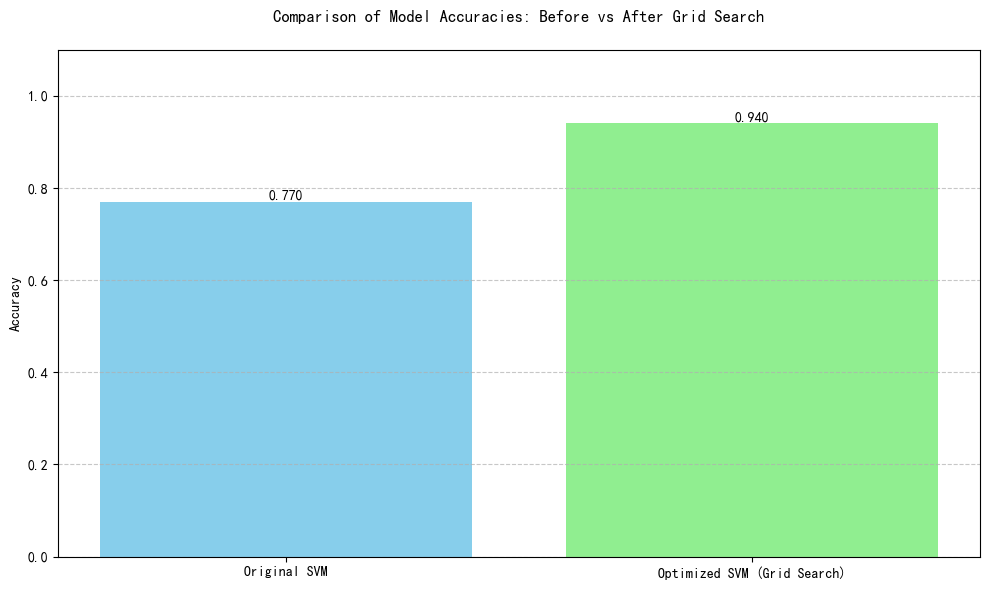

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 假设我们有以下数据（您需要用实际数据替换这些值）
# 网格搜索前的准确率（原始SVM模型）
original_accuracy = accuracy  # 替换为您实际的原始模型准确率

# 网格搜索后的准确率（最佳模型）
best_accuracy = accuracy1

# 模型标签
models = ['Original SVM', 'Optimized SVM (Grid Search)']

# 准确率值
accuracies = [original_accuracy, best_accuracy]

# 创建柱状图
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])

# 添加准确率数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')

# 设置图表标题和标签
plt.title('Comparison of Model Accuracies: Before vs After Grid Search', pad=20)
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)  # 设置y轴范围，留出空间给数值标签

# 显示网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示图表
plt.tight_layout()
plt.show()